In [5]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

DATA_DIR = Path("/content/drive/MyDrive/STATS201_project/torres_replication/")
CAPSULE_DATA = DATA_DIR / "capsule" / "data"
IMAGES_DIR = CAPSULE_DATA / "Images2"

print("DATA_DIR exists:", DATA_DIR.exists())
print("CAPSULE_DATA exists:", CAPSULE_DATA.exists())
print("IMAGES_DIR exists:", IMAGES_DIR.exists())

meta_path = CAPSULE_DATA / "metadata_caravan_media_short.csv"
clusters_path = CAPSULE_DATA / "clusters_preds_caravan_newsapi.csv"

print("meta_path exists:", meta_path.exists())
print("clusters_path exists:", clusters_path.exists())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_DIR exists: True
CAPSULE_DATA exists: True
IMAGES_DIR exists: True
meta_path exists: True
clusters_path exists: True


In [6]:
meta = pd.read_csv(meta_path, encoding="latin1")
clusters = pd.read_csv(clusters_path)

In [7]:
import pandas as pd
import os

df = meta

print("Metadata shape:", df.shape)
df.head(3)


Metadata shape: (688, 15)


,imageid,articleid,domain,screen_name2,newspapername,newspaperid,author,title,description,date,ideol_allsides,iscrowd,istrump,date2,topicality
0,abc-news_0000_11.jpg,abc-news_0000,abcnews.go.com,abc,ABC News,abc-news,b'ABC News',"b""WATCH: President Trump calls caravan migrant...",b'In an exclusive interview with ABC News Trum...,b'2018-11-01T17:05:40Z',left-center,0,1,11/1/18,0.0
1,abc-news_0001_1.jpg,abc-news_0001,abcnews.go.com,abc,ABC News,abc-news,b'The Associated Press',"b'56,800 dead and missing: The hidden toll of ...","b""An Associated Press tally has documented mor...",b'2018-11-01T16:22:37Z',left-center,0,0,11/1/18,0.0
2,abc-news_0002_1.jpg,abc-news_0002,abcnews.go.com,abc,ABC News,abc-news,b'The Associated Press',b'The Latest: Migrant caravan sets off toward ...,b'Thousands of Central American migrants have ...,b'2018-11-01T13:08:09Z',left-center,0,0,11/1/18,0.0


In [8]:
print("Columns:", list(df.columns))
y = df["iscrowd"].astype(int)

print("\nLabel counts:")
print(y.value_counts())

print("\nLabel proportions:")
print(y.value_counts(normalize=True))


Columns: ['imageid', 'articleid', 'domain', 'screen_name2', 'newspapername', 'newspaperid', 'author', 'title', 'description', 'date', 'ideol_allsides', 'iscrowd', 'istrump', 'date2', 'topicality']

Label counts:
iscrowd
0    561
1    127
Name: count, dtype: int64

Label proportions:
iscrowd
0    0.815407
1    0.184593
Name: proportion, dtype: float64


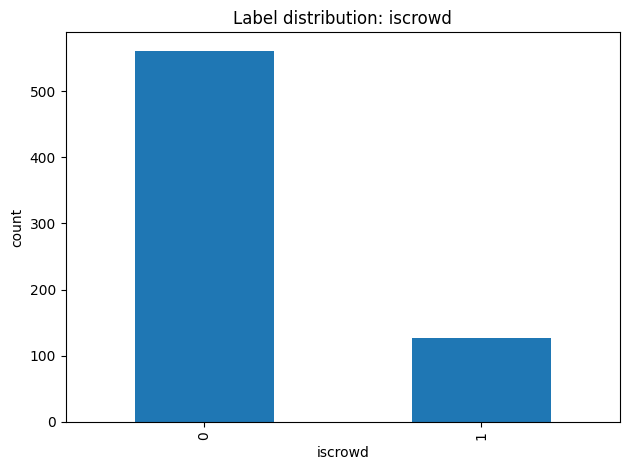

In [9]:
import matplotlib.pyplot as plt

y.value_counts().plot(kind="bar")
plt.title("Label distribution: iscrowd")
plt.xlabel("iscrowd")
plt.ylabel("count")
plt.tight_layout()
plt.show()


In [11]:
import pandas as pd, os

pred = clusters

# remove trailing ".p" if present
pred["imageid"] = pred["file"].astype(str).str.replace(r"\.p$", "", regex=True)

dfm = df.merge(pred[["imageid", "predicted_labels"]], on="imageid", how="inner")
print("Matched rows:", dfm.shape[0])
dfm.head()

print("Metadata rows:", df.shape[0])
print("Matched rows:", dfm.shape[0])
print(dfm[["imageid","iscrowd","predicted_labels"]].head())


Matched rows: 517
Metadata rows: 688
Matched rows: 517
                imageid  iscrowd  predicted_labels
0  abc-news_0000_11.jpg        0                 3
1   abc-news_0001_1.jpg        0                 7
2   abc-news_0002_1.jpg        0                 6
3   abc-news_0003_2.jpg        0                 5
4   abc-news_0003_3.jpg        0                 8


In [12]:
from sklearn.model_selection import train_test_split

y = dfm["iscrowd"].astype(int)
X = dfm[["predicted_labels"]]

print("df:", df.shape, " dfm:", dfm.shape)
print("X:", X.shape, " y:", y.shape)
assert X.shape[0] == y.shape[0], "X and y row counts do not match!"


X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


df: (688, 15)  dfm: (517, 16)
X: (517, 1)  y: (517,)
iscrowd
0    0.789474
1    0.210526
Name: proportion, dtype: float64
iscrowd
0    0.788462
1    0.211538
Name: proportion, dtype: float64


In [13]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

maj_label = y_train.value_counts().idxmax()
y_pred_maj = np.full_like(y_test, fill_value=maj_label)

print("Majority label:", maj_label)
print("Accuracy:", accuracy_score(y_test, y_pred_maj))
print(confusion_matrix(y_test, y_pred_maj))
print(classification_report(y_test, y_pred_maj, digits=3))


Majority label: 0
Accuracy: 0.7884615384615384
[[123   0]
 [ 33   0]]
              precision    recall  f1-score   support

           0      0.788     1.000     0.882       123
           1      0.000     0.000     0.000        33

    accuracy                          0.788       156
   macro avg      0.394     0.500     0.441       156
weighted avg      0.622     0.788     0.695       156



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [14]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

cat_features = ["predicted_labels"]

preprocess = ColumnTransformer(
    transformers=[("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)],
    remainder="drop"
)

clf = Pipeline(steps=[
    ("prep", preprocess),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=3))


Confusion matrix:
 [[110  13]
 [  7  26]]
              precision    recall  f1-score   support

           0      0.940     0.894     0.917       123
           1      0.667     0.788     0.722        33

    accuracy                          0.872       156
   macro avg      0.803     0.841     0.819       156
weighted avg      0.882     0.872     0.876       156



In [15]:
# estimate P(y=1 | cluster) on training set
train_tbl = pd.DataFrame({"cluster": X_train["predicted_labels"], "y": y_train})
p1_by_cluster = train_tbl.groupby("cluster")["y"].mean()

# predict probability for test clusters (fallback to overall rate if unseen cluster)
overall_p = y_train.mean()
p_test = X_test["predicted_labels"].map(p1_by_cluster).fillna(overall_p)

# pick threshold (0.5 is default baseline; later you can tune)
y_pred_cluster = (p_test >= 0.5).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_cluster))
print(confusion_matrix(y_test, y_pred_cluster))
print(classification_report(y_test, y_pred_cluster, digits=3))


Accuracy: 0.8717948717948718
[[110  13]
 [  7  26]]
              precision    recall  f1-score   support

           0      0.940     0.894     0.917       123
           1      0.667     0.788     0.722        33

    accuracy                          0.872       156
   macro avg      0.803     0.841     0.819       156
weighted avg      0.882     0.872     0.876       156



In [16]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipe = Pipeline([
    ("oh", OneHotEncoder(handle_unknown="ignore")),
    ("logit", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

pipe.fit(X_train, y_train)
y_pred_logit = pipe.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_logit))
print(confusion_matrix(y_test, y_pred_logit))
print(classification_report(y_test, y_pred_logit, digits=3))


Accuracy: 0.8717948717948718
[[110  13]
 [  7  26]]
              precision    recall  f1-score   support

           0      0.940     0.894     0.917       123
           1      0.667     0.788     0.722        33

    accuracy                          0.872       156
   macro avg      0.803     0.841     0.819       156
weighted avg      0.882     0.872     0.876       156



In [17]:
print(df.shape, dfm.shape)


(688, 15) (517, 16)


In [18]:
print(X.shape, y.shape)


(517, 1) (517,)


In [19]:
from sklearn.metrics import f1_score, balanced_accuracy_score, roc_auc_score

print("F1 (class 1):", f1_score(y_test, y_pred))
print("Balanced acc:", balanced_accuracy_score(y_test, y_pred))

# if you have probabilities:
p = clf.predict_proba(X_test)[:,1]
print("ROC-AUC:", roc_auc_score(y_test, p))


F1 (class 1): 0.7222222222222222
Balanced acc: 0.8410938654841094
ROC-AUC: 0.8946784922394679


In [20]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=cv, scoring="f1")
print("CV F1 mean:", scores.mean(), "std:", scores.std())


CV F1 mean: 0.7168562939378076 std: 0.06706316295712339


In [21]:
from sklearn.metrics import balanced_accuracy_score, f1_score

print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred))
print("F1 (positive class=1):", f1_score(y_test, y_pred))


Balanced accuracy: 0.8410938654841094
F1 (positive class=1): 0.7222222222222222


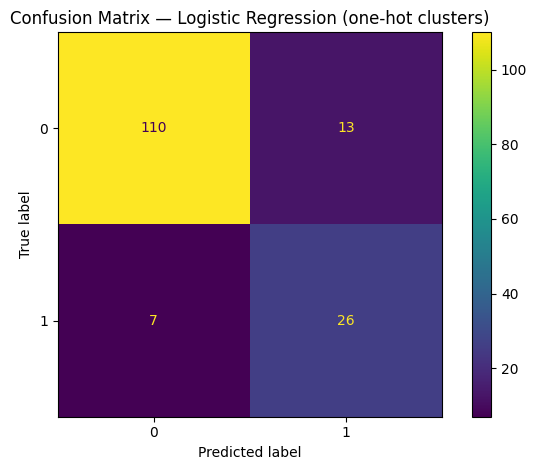

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)  # y_pred from your logistic model
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(values_format="d")
plt.title("Confusion Matrix — Logistic Regression (one-hot clusters)")
plt.tight_layout()
plt.savefig("confusion_matrix_logistic.png", dpi=200)
plt.show()


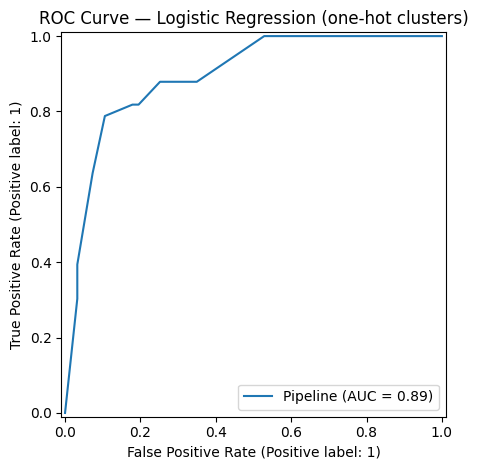

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(clf, X_test, y_test)  # clf = your pipeline logistic
plt.title("ROC Curve — Logistic Regression (one-hot clusters)")
plt.tight_layout()
plt.savefig("roc_curve_logistic.png", dpi=200)
plt.show()


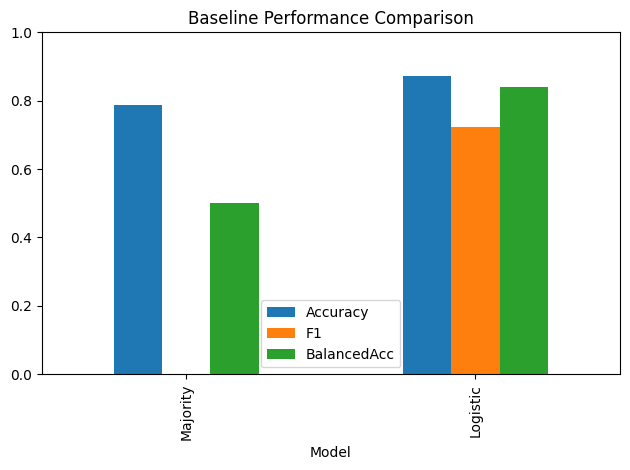

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, balanced_accuracy_score, accuracy_score

results = pd.DataFrame([
    {"Model":"Majority", "Accuracy": accuracy_score(y_test, y_pred_maj),
     "F1": f1_score(y_test, y_pred_maj), "BalancedAcc": balanced_accuracy_score(y_test, y_pred_maj)},
    {"Model":"Logistic", "Accuracy": accuracy_score(y_test, y_pred),
     "F1": f1_score(y_test, y_pred), "BalancedAcc": balanced_accuracy_score(y_test, y_pred)},
])

ax = results.set_index("Model")[["Accuracy","F1","BalancedAcc"]].plot(kind="bar")
plt.title("Baseline Performance Comparison")
plt.ylim(0,1)
plt.tight_layout()
plt.savefig("baseline_comparison.png", dpi=200)
plt.show()
